# Análise dos piores casos — onde os métodos erram

Grupo 02 — Segmentação do Parênquima Pulmonar. Etapa de **Interpretação** do KDD.

Orientação 5 do feedback da Sprint 3: olhar *onde* os métodos erram, e não só *quanto* acertam —
*"pode ser que a rede neural ganhe pouco na média e ganhe muito nos casos difíceis. Se for isso,
esse é o argumento que justifica o trabalho de vocês"*.

Os números do conjunto de teste (split 70/15/15, 26 pacientes) já apontam nessa direção: a U-Net
ganha muito mais Dice nos 3 piores exames do baseline do que nos outros 23 (seção 1). Este
notebook abre as imagens desses exames para explicar o porquê, e depois testa nos 26 exames se a
explicação se sustenta.

**O que tem aqui**

1. Ganho da U-Net nos piores casos × no resto, a partir dos CSVs oficiais.
2. Ferramentas (pré-processamento, figuras e tabela de erros).
3. Os exames: para cada um, os 3 métodos rodados com o mesmo pré-processamento da avaliação
   oficial e 3 fatias axiais (início, meio e fim do pulmão) com 5 painéis: TC, referência,
   baseline, region growing e U-Net. Abaixo das fatias, o perfil de erro ao longo do pulmão, e
   depois uma tabela com o tipo de erro de cada método.
   - os 3 piores exames do baseline;
   - 1 exame em que os 3 métodos vão bem (controle);
   - 1 exame em que a U-Net perde para o baseline (contraponto).
4. O padrão se repete nos 26 exames?
5. Figura para o slide.
6. Conclusão.

**Como ler as figuras**: em cada painel de método, **verde-água** = pulmão no método e na
referência (acerto), **laranja** = pulmão da referência que o método deixou de fora (falso
negativo), **azul** = o que o método incluiu a mais (falso positivo). O círculo tracejado no
painel TC marca um nódulo anotado no LUNA16 (`annotations.csv`), quando ele cruza a fatia.

**Escopo das descrições**: o texto descreve só o que é visível na imagem e o que é medido nela
(densidade em HU, posição, volume). Nenhuma frase aqui é diagnóstico.

**Como rodar**: a partir da raiz do repositório, com o `.venv` do projeto (precisa de `torch`).
Os caminhos são relativos (`data/luna16`) de propósito: caminho absoluto quebra a leitura do
SimpleITK nesta pasta. Os exames precisam estar baixados (`scripts/download_luna16_subset.py 0` e
`1`) e os pesos da U-Net em `data/luna16/unet_baseline.pt`. As figuras são salvas em
`docs/piores_casos/`. Tempo total em CPU: ~4 min.

In [1]:
import sys
sys.path.insert(0, 'src')

import functools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch
from scipy import ndimage
from scipy.stats import spearmanr

from luna16.io import load_ct, load_reference_mask, TRACHEA_LABEL
from luna16.pipeline import _to_sitk
from luna16.preprocessing import clean_hu, denoise, resample_isotropic
from luna16.baseline import segment_baseline, THRESHOLD_HU
from luna16.region_growing import segment_region_growing, SEED_THRESHOLD_HU, _find_seed_points
from luna16.lung_air import label_largest_components
from luna16.unet import load_trained_model, segment_with_unet
from luna16.metrics import dice_coefficient

# relativo de propósito: caminho absoluto quebra a leitura do SimpleITK nesta pasta
DATA_DIR = Path('data/luna16')
FIG_DIR = Path('docs/piores_casos')
assert (DATA_DIR / 'split_full.csv').exists(), 'rode o notebook a partir da raiz do repositório'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FRACOES_Z = [(0.2, 'Início — base (20%)'), (0.5, 'Meio (50%)'), (0.8, 'Fim — ápice (80%)')]

# sobreposição na TC: slots 1-3 da paleta categórica, passo escuro (validados para daltonismo)
COR_ACERTO, COR_FN, COR_FP = '#199e70', '#d95926', '#3987e5'
COR_METODO = {'Baseline': '#4a3aa7', 'Region growing': '#e87ba4', 'U-Net': '#008300'}
plt.rcParams['figure.dpi'] = 60  # só a exibição no notebook; os PNGs em docs/ saem com 150 dpi

def fmt(x, casas=3):
    """Número com vírgula decimal, para títulos de figura."""
    return f'{x:.{casas}f}'.replace('.', ',')

def curto(uid):
    return '…' + uid[-12:]

LIMIAR_TXT = f'{THRESHOLD_HU}'.replace('-', '−')  # sinal de menos tipográfico nos rótulos

## 1. O ganho da U-Net nos piores casos (CSVs oficiais)

Dice por exame dos 3 métodos no conjunto de teste, lido dos CSVs gerados pela avaliação oficial
(`sprint4_baseline_test.csv`, `sprint4_region_growing_test.csv`, `sprint_unet_test.csv`).

In [2]:
METODOS = {
    'Baseline': 'sprint4_baseline_test.csv',
    'Region growing': 'sprint4_region_growing_test.csv',
    'U-Net': 'sprint_unet_test.csv',
}
split = pd.read_csv(DATA_DIR / 'split_full.csv')
test_uids = set(split.loc[split['conjunto'] == 'test', 'uid'])

resultados = {}
for nome, arquivo in METODOS.items():
    df = pd.read_csv(DATA_DIR / arquivo).set_index('uid')
    assert set(df.index) == test_uids, f'{arquivo}: pacientes diferentes do conjunto de teste'
    resultados[nome] = df

dice = pd.DataFrame({nome: df['dice'] for nome, df in resultados.items()})
dice['Ganho U-Net − baseline'] = dice['U-Net'] - dice['Baseline']
dice = dice.sort_values('Baseline')

piores, outros = dice.iloc[:3], dice.iloc[3:]
resumo = pd.DataFrame({
    'N': [len(piores), len(outros), len(dice)],
    'Dice baseline': [piores['Baseline'].mean(), outros['Baseline'].mean(), dice['Baseline'].mean()],
    'Dice U-Net': [piores['U-Net'].mean(), outros['U-Net'].mean(), dice['U-Net'].mean()],
    'Ganho médio U-Net − baseline': [piores.iloc[:, 3].mean(), outros.iloc[:, 3].mean(), dice.iloc[:, 3].mean()],
}, index=['3 piores do baseline', 'outros 23', 'todos os 26'])
display(resumo.round(4))
display(dice.head(5).set_axis(dice.index[:5].map(curto)).round(4))

,N,Dice baseline,Dice U-Net,Ganho médio U-Net − baseline
3 piores do baseline,3,0.8729,0.9670,0.0941
outros 23,23,0.9663,0.9796,0.0133
todos os 26,26,0.9555,0.9781,0.0226


,Baseline,Region growing,U-Net,Ganho U-Net − baseline
uid,,,,
…658609808059,0.8468,0.7790,0.9671,0.1203
…021509831276,0.8600,0.5941,0.9628,0.1028
…954024478441,0.9119,0.9212,0.9710,0.0591
…604069960014,0.9518,0.9599,0.9687,0.0169
…918746541371,0.9544,0.9400,0.9817,0.0273


Nos 3 piores exames do baseline a U-Net ganha **+0,094** de Dice em média; nos outros 23, só
**+0,013**. A pergunta das próximas seções é *o que* esses 3 exames têm de diferente.

## 2. Ferramentas

`preparar_exame` repete o pré-processamento de `pipeline.run_pipeline_for_uid` (limpeza de HU,
filtro gaussiano σ=0,5, reamostragem para 1 mm isotrópico), mas devolve os volumes em vez das
métricas. Como o voxel final tem 1 mm³, contagens de voxels viram volume direto (1.000 voxels =
1 cm³). `segmentar` roda os 3 métodos e **confere que o Dice bate com o dos CSVs oficiais** —
garante que as figuras mostram exatamente as máscaras que geraram os números.

No LUNA16 o eixo z cresce em direção à cabeça (matriz de direção identidade, conferida em
`nodulos_no_volume`), então a fatia de 20% fica perto da base do pulmão e a de 80% perto do ápice.

In [3]:
def preparar_exame(uid):
    ct = load_ct(uid, DATA_DIR)
    ct_sitk = ct.to_sitk_image()
    vol_sitk = _to_sitk(denoise(clean_hu(ct.array), sigma=0.5), ct_sitk, 'int16')
    vol = sitk.GetArrayFromImage(resample_isotropic(vol_sitk, (1.0, 1.0, 1.0)))

    def mascara_1mm(array):
        img = resample_isotropic(_to_sitk(array, ct_sitk, 'uint8'), (1.0, 1.0, 1.0), is_mask=True)
        return sitk.GetArrayFromImage(img)

    # rótulos da referência: 3 = pulmão direito, 4 = esquerdo, 5 = traqueia/brônquios (ver io.py)
    rotulos = sitk.GetArrayFromImage(sitk.ReadImage(str(DATA_DIR / 'seg-lungs-LUNA16' / f'{uid}.mhd')))
    rotulos_1mm = mascara_1mm(rotulos)
    return {
        'uid': uid,
        'vol': vol,
        'ref': mascara_1mm(load_reference_mask(uid, DATA_DIR)).astype(bool),
        'rotulos': rotulos_1mm,
        # via aérea fica fora do parênquima de propósito na referência
        'via_aerea': rotulos_1mm == TRACHEA_LABEL,
        'spacing': ct.spacing,
        'origin': ct.origin,
        'direction': ct.direction,
    }


modelo_unet = load_trained_model(str(DATA_DIR / 'unet_baseline.pt'))
SEGMENTADORES = {
    'Baseline': segment_baseline,
    'Region growing': segment_region_growing,
    'U-Net': functools.partial(segment_with_unet, model=modelo_unet),
}


def segmentar(exame):
    exame['pred'] = {nome: fn(exame['vol']) for nome, fn in SEGMENTADORES.items()}
    exame['dice'] = {nome: dice_coefficient(p, exame['ref']) for nome, p in exame['pred'].items()}
    for nome, d in exame['dice'].items():
        oficial = resultados[nome].loc[exame['uid'], 'dice']
        assert abs(d - oficial) < 1e-3, f'{nome}: Dice {d:.4f} diferente do CSV oficial {oficial:.4f}'
    return exame


ANOTACOES_PATH = DATA_DIR / 'annotations.csv'
ANOTACOES = pd.read_csv(ANOTACOES_PATH) if ANOTACOES_PATH.exists() else None


def nodulos_no_volume(exame):
    """Nódulos do annotations.csv (coordenadas de mundo, mm) em índice (z, y, x) do volume
    reamostrado -- 1 mm por voxel e mesma origem, então índice = mundo - origem."""
    if ANOTACOES is None:
        return []
    assert np.allclose(exame['direction'], np.eye(3).ravel()), 'conversão assume direção identidade'
    ox, oy, oz = exame['origin']
    linhas = ANOTACOES[ANOTACOES['seriesuid'] == exame['uid']]
    return [(r.coordZ - oz, r.coordY - oy, r.coordX - ox, r.diameter_mm) for r in linhas.itertuples()]


def mascara_corpo(vol):
    """Corpo do paciente fatia a fatia: maior componente acima de -400 HU, com buracos
    preenchidos (o pulmão fica dentro). A mesa do tomógrafo é outro componente e fica de fora."""
    corpo = np.zeros(vol.shape, dtype=bool)
    for z, fatia in enumerate(vol > -400):
        rotulado, n = ndimage.label(fatia)
        if n:
            maior = np.bincount(rotulado.ravel())[1:].argmax() + 1
            corpo[z] = ndimage.binary_fill_holes(rotulado == maior)
    return corpo

In [4]:
LEGENDA_SOBREPOSICAO = [
    Patch(facecolor=COR_ACERTO, alpha=0.6, label='pulmão no método e na referência (acerto)'),
    Patch(facecolor=COR_FN, label='pulmão da referência que o método deixou de fora (falso negativo)'),
    Patch(facecolor=COR_FP, label='incluído a mais pelo método (falso positivo)'),
]
COR_NODULO = '#eda100'  # slot 4 da paleta: visível sobre a TC e sobre o fundo branco da legenda
LEGENDA_NODULO = Line2D([], [], color=COR_NODULO, ls='--', lw=1.5, label='nódulo anotado no LUNA16 (painel TC)')


def escolher_fatias(ref):
    zs = np.where(ref.any(axis=(1, 2)))[0]
    return [int(round(zs.min() + q * (zs.max() - zs.min()))) for q, _ in FRACOES_Z]


def recorte(exame, margem=10):
    """Mesmo recorte em todos os painéis: caixa que contém a referência e as 3 predições."""
    uniao = exame['ref'].copy()
    for p in exame['pred'].values():
        uniao |= p
    ys = np.where(uniao.any(axis=(0, 2)))[0]
    xs = np.where(uniao.any(axis=(0, 1)))[0]
    return (slice(max(ys.min() - margem, 0), ys.max() + margem + 1),
            slice(max(xs.min() - margem, 0), xs.max() + margem + 1))


def sobrepor(ax, ct, ref, pred=None):
    ax.imshow(ct, cmap='gray', vmin=-1000, vmax=200, interpolation='nearest')
    rgba = np.zeros(ct.shape + (4,))
    if pred is None:
        rgba[ref] = to_rgba(COR_ACERTO, 0.45)
    else:
        rgba[ref & pred] = to_rgba(COR_ACERTO, 0.30)
        rgba[ref & ~pred] = to_rgba(COR_FN, 0.90)
        rgba[pred & ~ref] = to_rgba(COR_FP, 0.90)
    ax.imshow(rgba, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])


def rotulo_canto(ax, texto):
    ax.text(0.02, 0.03, texto, transform=ax.transAxes, color='white', fontsize=9,
            bbox=dict(facecolor='black', alpha=0.65, pad=2, linewidth=0))


def desenhar_linha_de_fatias(ax, exame, fatias, ry, rx, titulos_com_dice=True):
    """Uma linha de 5 painéis para cada fatia em `fatias` (lista de (z, rótulo))."""
    vol, ref, pred = exame['vol'], exame['ref'], exame['pred']
    nodulos = nodulos_no_volume(exame)
    algum_nodulo = False
    for linha, (z, rotulo) in enumerate(fatias):
        ct, r = vol[z, ry, rx], ref[z, ry, rx]
        ax[linha, 0].imshow(ct, cmap='gray', vmin=-1000, vmax=200, interpolation='nearest')
        ax[linha, 0].set_xticks([])
        ax[linha, 0].set_yticks([])
        ax[linha, 0].set_ylabel(rotulo, fontsize=11)
        for nz, ny, nx, diam in nodulos:
            if abs(nz - z) <= diam / 2:
                ax[linha, 0].add_patch(Circle((nx - rx.start, ny - ry.start), diam / 2 + 5,
                                              fill=False, ec=COR_NODULO, ls='--', lw=1.5))
                algum_nodulo = True
        sobrepor(ax[linha, 1], ct, r)
        for coluna, (nome, p) in enumerate(pred.items(), start=2):
            sobrepor(ax[linha, coluna], ct, r, p[z, ry, rx])
            rotulo_canto(ax[linha, coluna], f'Dice da fatia {fmt(dice_coefficient(p[z, ry, rx], r), 2)}')
    titulos = ['TC (janela de pulmão)', 'Referência'] + [
        f'{nome}\nDice do exame {fmt(exame["dice"][nome])}' if titulos_com_dice else nome for nome in pred]
    for coluna, t in enumerate(titulos):
        ax[0, coluna].set_title(t, fontsize=12)
    return algum_nodulo


def figura_exame(exame, chave, titulo):
    vol, ref, pred = exame['vol'], exame['ref'], exame['pred']
    zsel = escolher_fatias(ref)
    ry, rx = recorte(exame)
    aspecto = (ry.stop - ry.start) / (rx.stop - rx.start)
    h_img = 3.3 * aspecto
    fig = plt.figure(figsize=(17, 3 * h_img + 4.6), layout='constrained')
    sub_img, sub_perfil = fig.subfigures(2, 1, height_ratios=[3 * h_img + 0.9, 3.7])

    ax = sub_img.subplots(3, 5)
    fatias = [(z, rotulo) for z, (_, rotulo) in zip(zsel, FRACOES_Z)]
    algum_nodulo = desenhar_linha_de_fatias(ax, exame, fatias, ry, rx)
    sx, sy, sz = exame['spacing']
    sub_img.suptitle(f'{titulo} — exame {curto(exame["uid"])} (voxel original {fmt(sx, 2)} × {fmt(sy, 2)} × {fmt(sz, 2)} mm)',
                     fontsize=14)

    # perfil de erro ao longo do pulmão: área por fatia (1 voxel = 1 mm², /100 = cm²)
    zs = np.where(ref.any(axis=(1, 2)))[0]
    eixo_z = np.arange(vol.shape[0]) - zs.min()
    ax_fn, ax_fp = sub_perfil.subplots(1, 2)
    for nome, p in pred.items():
        ax_fn.plot(eixo_z, (ref & ~p).sum(axis=(1, 2)) / 100, color=COR_METODO[nome], lw=1.6, label=nome)
        ax_fp.plot(eixo_z, (p & ~ref).sum(axis=(1, 2)) / 100, color=COR_METODO[nome], lw=1.6, label=nome)
    densa = (ref & (vol >= THRESHOLD_HU)).sum(axis=(1, 2)) / 100
    ax_fn.plot(eixo_z, densa, color='#0b0b0b', ls='--', lw=1.2, label=f'referência com HU ≥ {LIMIAR_TXT}')
    for a, t in [(ax_fn, 'Pulmão deixado de fora (falso negativo) por fatia'),
                 (ax_fp, 'Incluído a mais (falso positivo) por fatia')]:
        for z in zsel:
            a.axvline(z - zs.min(), color='#c3c2b7', lw=1, zorder=0)
        a.set_xlim(-10, zs.max() - zs.min() + 10)
        a.set_ylim(bottom=0)
        a.set_title(t, fontsize=11)
        a.set_xlabel('posição da fatia (mm a partir da base do pulmão); linhas cinza = fatias mostradas')
        a.set_ylabel('área na fatia (cm²)')
        a.grid(axis='y', color='#e1e0d9', lw=0.6)
        a.spines[['top', 'right']].set_visible(False)
        a.legend(fontsize=9, frameon=False)

    legenda = LEGENDA_SOBREPOSICAO + ([LEGENDA_NODULO] if algum_nodulo else [])
    sub_img.legend(handles=legenda, loc='outside lower center', ncol=len(legenda), fontsize=10, frameon=False)
    caminho = FIG_DIR / f'{chave}_{exame["uid"][-12:]}.png'
    fig.savefig(caminho, dpi=150, facecolor='white')
    plt.show()
    print(f'figura salva em {caminho}')


def tabela_erros(exame):
    vol, ref = exame['vol'], exame['ref']
    perto_da_borda = ref & (ndimage.distance_transform_edt(ref) <= 2)
    corpo = mascara_corpo(vol)
    linhas = {}
    for nome, p in exame['pred'].items():
        fn, fp = ref & ~p, p & ~ref
        linhas[nome] = {
            'Dice': exame['dice'][nome],
            'Deixado de fora (cm³)': fn.sum() / 1000,
            '… a ≤ 2 mm da borda (%)': 100 * (fn & perto_da_borda).sum() / max(fn.sum(), 1),
            '… HU mediano': np.median(vol[fn]) if fn.any() else np.nan,
            '… acima de −100 HU (%)': 100 * (vol[fn] > -100).mean() if fn.any() else 0.0,
            'Incluído a mais (cm³)': fp.sum() / 1000,
            '… em traqueia/brônquios (%)': 100 * (fp & exame['via_aerea']).sum() / max(fp.sum(), 1),
            '… fora do corpo (%)': 100 * (fp & ~corpo).sum() / max(fp.sum(), 1),
        }
    densa = ref & (vol >= THRESHOLD_HU)
    ys = np.where(ref.any(axis=(0, 2)))[0]
    y_meio = (ys.min() + ys.max()) / 2  # y cresce para trás (posterior) no LUNA16
    posterior = densa[:, int(np.ceil(y_meio)):, :].sum() / max(densa.sum(), 1)
    print(f'Referência: {ref.sum() / 1e6:.2f} L de pulmão; {100 * densa.sum() / ref.sum():.1f}% dele com HU ≥ {LIMIAR_TXT} '
          f'({100 * posterior:.0f}% dessa parte densa na metade posterior)')
    tabela = pd.DataFrame(linhas).T
    return tabela.style.format('{:.3f}', subset=['Dice']).format(
        '{:.0f}', subset=[c for c in tabela.columns if c != 'Dice'])


def analisar(uid, chave, titulo):
    exame = segmentar(preparar_exame(uid))
    figura_exame(exame, chave, titulo)
    display(tabela_erros(exame))
    return exame


exames_slide = {}  # só os 2 exames da figura do slide ficam em memória (~300 MB cada)

**Leitura da tabela de erros** (uma linha por método):

- *Deixado de fora*: volume do pulmão da referência que o método não marcou. "a ≤ 2 mm da borda" separa
  erro de contorno (borda fina) de erro de região (pedaços inteiros do pulmão). "HU mediano" e
  "acima de −100 HU" dizem que densidade tem o que ficou de fora — densidade de líquido ou de partes
  moles fica perto de 0 HU, então uma fração baixa acima de −100 HU indica que não é isso.
- *Incluído a mais*: volume marcado pelo método que a referência não considera pulmão. A referência
  exclui de propósito a traqueia e os brônquios principais (rótulo 5), por isso essa parcela aparece
  separada; "fora do corpo" é ar externo ao paciente (por exemplo, entre as costas e a mesa).

## 3. Os exames

Os 3 piores do baseline, na ordem; depois o controle e o contraponto. Para cada um: figura,
tabela de erros e interpretação.

## 3.1 Caso 1 — …658609808059 (pior Dice do baseline)

Dice: baseline **0,847** · region growing **0,779** · U-Net **0,967**.

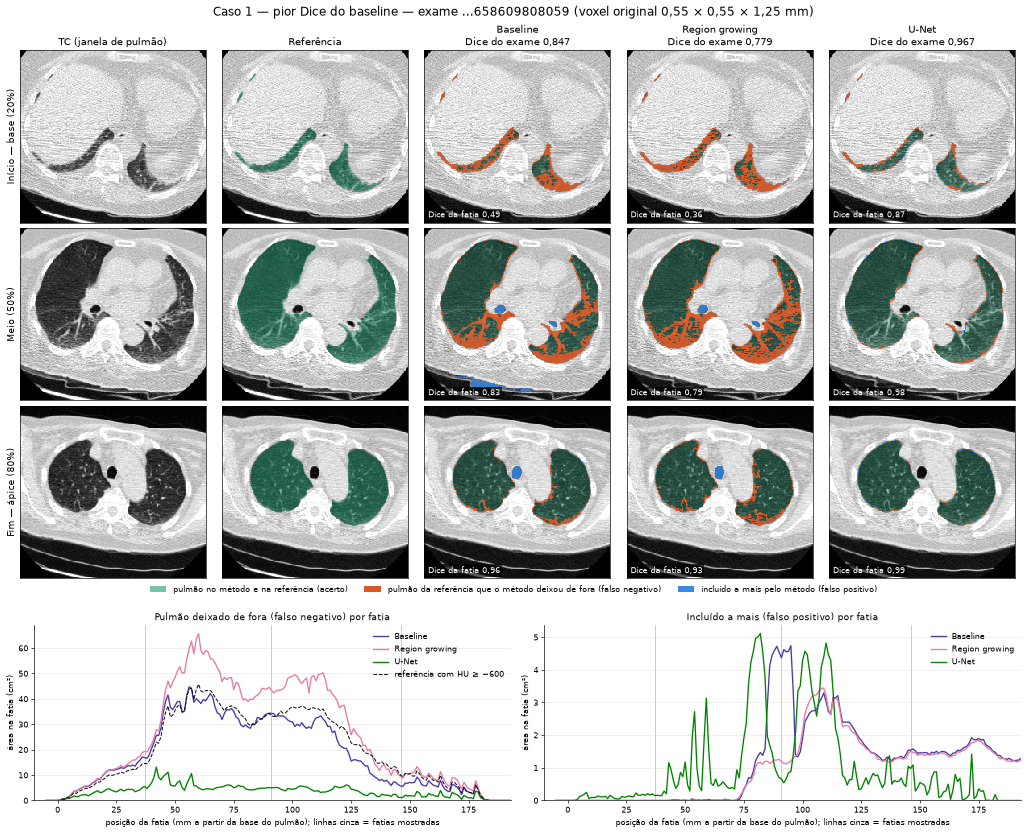

figura salva em docs\piores_casos\caso1_658609808059.png


Referência: 1.40 L de pulmão; 27.6% dele com HU ≥ −600 (78% dessa parte densa na metade posterior)


,Dice,Deixado de fora (cm³),… a ≤ 2 mm da borda (%),… HU mediano,… acima de −100 HU (%),Incluído a mais (cm³),… em traqueia/brônquios (%),… fora do corpo (%)
Baseline,0.847,354,40,-483,4,24,78,16
Region growing,0.779,494,32,-533,3,20,90,0
U-Net,0.967,71,90,-369,8,19,28,0


In [5]:
exames_slide['caso1'] = analisar('1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059', 'caso1', 'Caso 1 — pior Dice do baseline')

**O que a imagem mostra.** O pulmão não aparece preto e homogêneo: tem textura granulada e áreas
cinza de densidade intermediária, mais fortes na metade posterior e nas bases — na fatia da base, o
pulmão direito é só uma faixa estreita junto às costas. É o menor pulmão dos 26 (1,4 L na
referência), a imagem tem bastante ruído (faixas horizontais nos tecidos moles) e não há sinal de
líquido: o HU mediano do que o baseline deixou de fora é −483, logo acima do limiar, e só 4% passa
de −100 HU.

**Por que cada método errou ou acertou**

- **Baseline (0,847)**: 28% do pulmão da referência está acima de −600 HU, e o limiar recorta
  exatamente essa parte — no perfil, a área perdida pelo baseline acompanha quase fatia a fatia a
  linha tracejada do pulmão denso. O pulmão vira uma "renda" de ilhas incluídas e excluídas, e a
  região posterior fica de fora. O que ele inclui a mais é quase todo traqueia e brônquios (78%),
  mais uma faixa de ar entre as costas e a mesa na fatia do meio.
- **Region growing (0,779)**: mesma limitação, mais forte — o crescimento só aceita voxels a até
  ±200 HU da semente, que fica no ar mais escuro do pulmão, e para antes de chegar nas áreas cinza.
- **U-Net (0,967)**: preenche as áreas densas, porque decide pela forma e pelo contexto da fatia, e
  não pelo HU de cada voxel isolado; 90% do pouco que ela deixa de fora está a até 2 mm da borda. Ela
  também não inclui a traqueia.

## 3.2 Caso 2 — …021509831276 (fatias de 2,5 mm)

Dice: baseline **0,860** · region growing **0,594** · U-Net **0,963**.

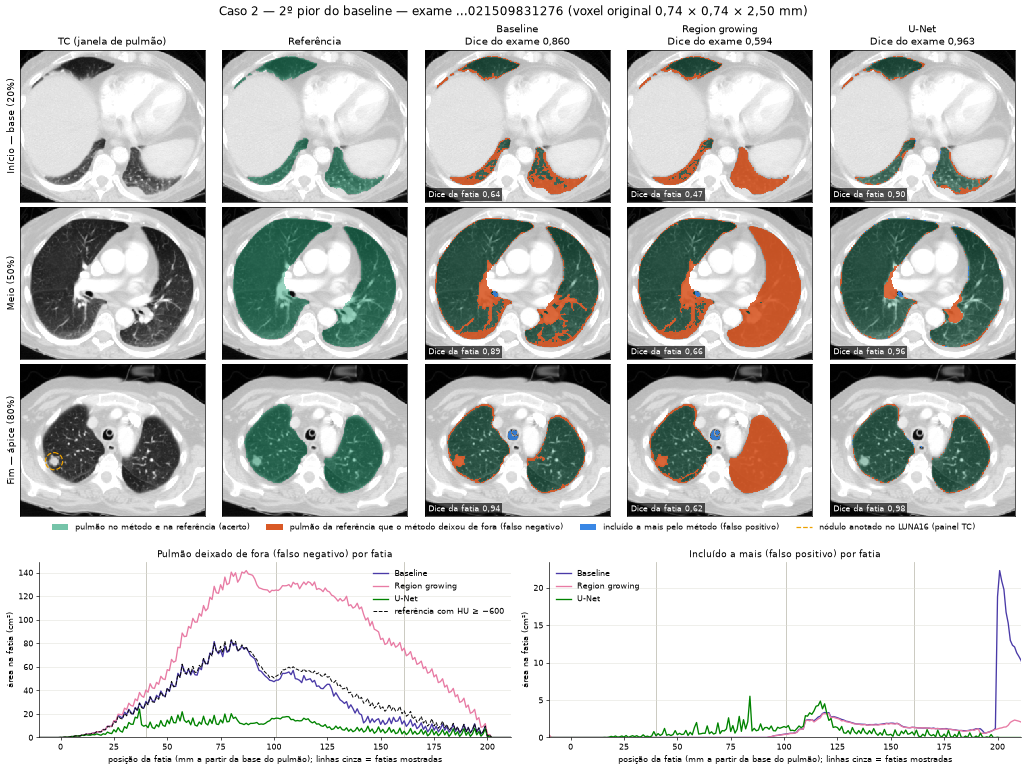

figura salva em docs\piores_casos\caso2_021509831276.png


Referência: 2.64 L de pulmão; 26.3% dele com HU ≥ −600 (80% dessa parte densa na metade posterior)


,Dice,Deixado de fora (cm³),… a ≤ 2 mm da borda (%),… HU mediano,… acima de −100 HU (%),Incluído a mais (cm³),… em traqueia/brônquios (%),… fora do corpo (%)
Baseline,0.860,621,37,-459,11,37,45,6
Region growing,0.594,1513,19,-630,5,32,52,0
U-Net,0.963,175,72,-347,20,16,17,0


In [6]:
exame = analisar('1.3.6.1.4.1.14519.5.2.1.6279.6001.503980049263254396021509831276', 'caso2', 'Caso 2 — 2º pior do baseline')

In [7]:
# Region growing no caso 2: onde caíram as 2 sementes e quanto de cada pulmão ele cobriu
vol, ref, rotulos = exame['vol'], exame['ref'], exame['rotulos']
base_do_pulmao = np.where(ref.any(axis=(1, 2)))[0].min()

# Lado de cada rótulo pela geometria, não pelo nome: no LUNA16 (direção identidade, convenção
# LPS) o x cresce para a esquerda do paciente, então o rótulo com x médio menor é o pulmão direito.
# (Nos exames conferidos, isso dá 4 = direito e 3 = esquerdo, o contrário da docstring de io.py.)
x_medio = {r: np.nonzero(rotulos == r)[2].mean() for r in (3, 4)}
direito = min(x_medio, key=x_medio.get)
NOME_PULMAO = {r: 'pulmão direito' if r == direito else 'pulmão esquerdo' for r in (3, 4)}
print(f'rótulo {direito} = pulmão direito, rótulo {7 - direito} = pulmão esquerdo (pela posição em x)\n')

rotulado, mantidos = label_largest_components(vol < SEED_THRESHOLD_HU, n_keep=2)
for i, (rotulo, semente) in enumerate(zip(mantidos, _find_seed_points(rotulado, mantidos)), 1):
    comp = rotulado == rotulo
    contem = ', '.join(f'{(comp & (rotulos == r)).sum() / 1000:.0f} cm³ do {n}' for r, n in NOME_PULMAO.items())
    onde = NOME_PULMAO.get(int(rotulos[semente]), 'fora do pulmão da referência')
    print(f'componente {i} (< {SEED_THRESHOLD_HU} HU): {comp.sum() / 1000:.1f} cm³, contém {contem}')
    print(f'   semente a {semente[0] - base_do_pulmao:+d} mm da base do pulmão (negativo = abaixo dela), '
          f'{vol[semente]} HU, {onde}')

rg = exame['pred']['Region growing']
for r, n in NOME_PULMAO.items():
    pulmao = rotulos == r
    print(f'{n}: {pulmao.sum() / 1000:.0f} cm³ na referência, {100 * (rg & pulmao).sum() / pulmao.sum():.0f}% coberto pelo region growing')

rótulo 4 = pulmão direito, rótulo 3 = pulmão esquerdo (pela posição em x)


componente 1 (< -320 HU): 2523.2 cm³, contém 1060 cm³ do pulmão esquerdo, 1412 cm³ do pulmão direito
   semente a +92 mm da base do pulmão (negativo = abaixo dela), -840 HU, pulmão direito


componente 2 (< -320 HU): 19.4 cm³, contém 0 cm³ do pulmão esquerdo, 0 cm³ do pulmão direito
   semente a -34 mm da base do pulmão (negativo = abaixo dela), -939 HU, fora do pulmão da referência
pulmão esquerdo: 1145 cm³ na referência, 0% coberto pelo region growing


pulmão direito: 1497 cm³ na referência, 75% coberto pelo region growing


**O que a imagem mostra.** Nas bases, a parte posterior do pulmão aparece cinza e granulada; em
volta do hilo há bastante tecido denso junto aos vasos; e o LUNA16 anota dois nódulos no pulmão
direito, de 12 e 15 mm — o que cruza a fatia do ápice está circulado e fica junto à parede lateral.
Entre as fatias do início e do meio (~80 mm acima da base) há ainda uma área densa no pulmão direito
junto ao hilo, que é onde o erro do baseline faz o pico no perfil. As fatias originais têm 2,5 mm,
mas a espessura não explica o erro: nos 26 exames ela não tem relação significativa com o ganho da
U-Net (seção 4).

**Por que cada método errou ou acertou**

- **Baseline (0,860)**: perde a faixa posterior das bases e o tecido em volta dos vasos do hilo
  (26% do pulmão está acima de −600 HU). O preenchimento de buracos não recupera nem os vasos ligados
  ao mediastino nem o nódulo encostado na parede, porque nenhum dos dois fica cercado de ar — e só o
  que fica cercado de ar conta como buraco.
- **Region growing (0,594)**: falha de outro tipo, mostrada na célula acima. No limiar auxiliar de
  −320 HU os dois pulmões formam um único componente, então a 2ª semente cai num bolsão de ar de
  ~19 cm³ a 34 mm abaixo da base do pulmão, sem nenhum voxel de pulmão. A única semente pulmonar,
  no pulmão direito, não alcança o esquerdo, que fica inteiro de fora (sensibilidade 0,43); mesmo
  no direito ele cobre só 75%, pelo mesmo motivo do baseline.
- **U-Net (0,963)**: inclui o nódulo, a região posterior e a maior parte do tecido em volta dos
  vasos; o que ela ainda perde fica junto ao hilo e na borda (72% a até 2 mm do contorno).

## 3.3 Caso 3 — …954024478441

Dice: baseline **0,912** · region growing **0,921** · U-Net **0,971**.

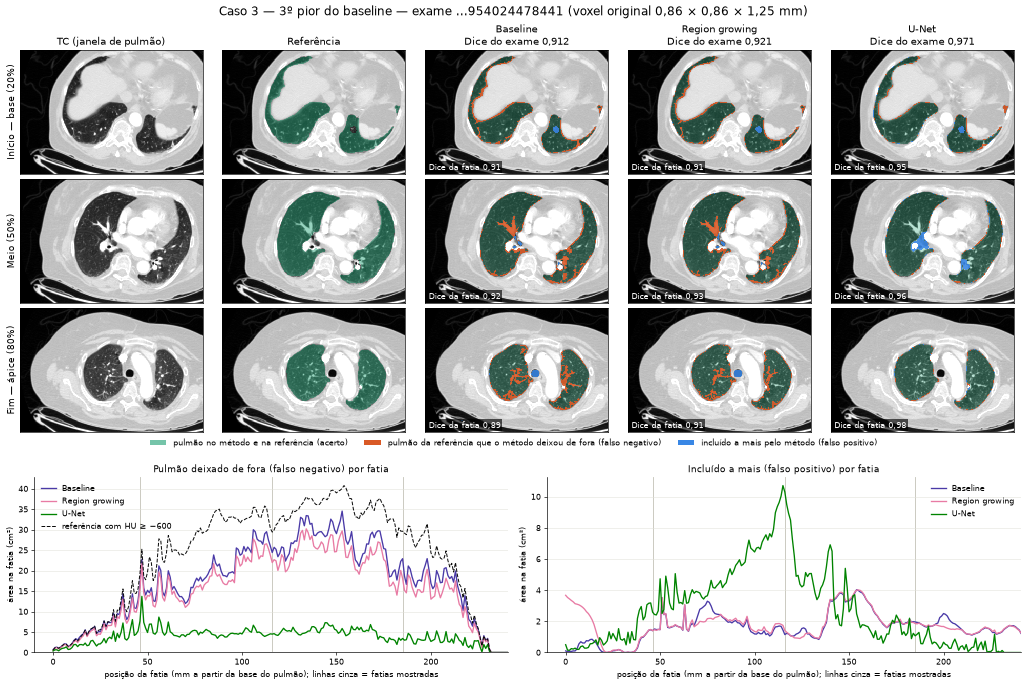

figura salva em docs\piores_casos\caso3_954024478441.png


Referência: 2.80 L de pulmão; 20.2% dele com HU ≥ −600 (78% dessa parte densa na metade posterior)


,Dice,Deixado de fora (cm³),… a ≤ 2 mm da borda (%),… HU mediano,… acima de −100 HU (%),Incluído a mais (cm³),… em traqueia/brônquios (%),… fora do corpo (%)
Baseline,0.912,420,49,-487,8,40,77,7
Region growing,0.921,372,51,-470,9,44,72,0
U-Net,0.971,96,93,-421,6,66,26,0


In [8]:
exame = analisar('1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583497382954024478441', 'caso3', 'Caso 3 — 3º pior do baseline')

**O que a imagem mostra.** O parênquima é mais escuro e homogêneo que nos casos 1 e 2, mas os vasos
são bem visíveis, ramificando a partir do hilo, e há manchas de densidade intermediária na parte de
trás do pulmão: 20% da referência está acima de −600 HU, e 78% dessa parte fica na metade posterior.

**Por que cada método errou ou acertou**

- **Baseline (0,912) e region growing (0,921)** erram juntos e do mesmo jeito: deixam de fora a
  "árvore" de vasos que sai do hilo (laranja ramificado nas fatias do meio e do ápice) e uma borda
  posterior. Vaso isolado dentro do pulmão é recuperado pelo preenchimento de buracos; vaso que se
  liga ao mediastino, não. Aqui o region growing empata com o baseline porque as sementes caíram nos
  dois pulmões.
- **U-Net (0,971)**: inclui os vasos e a borda posterior. O erro dela vai para o outro lado: inclui
  um pouco de brônquio e tecido do hilo a mais (azul na fatia do meio).

## 3.4 Controle — …741695800950 (os 3 métodos vão bem)

Dice: baseline **0,982** · region growing **0,976** · U-Net **0,990**. Melhor Dice do baseline nos 26.

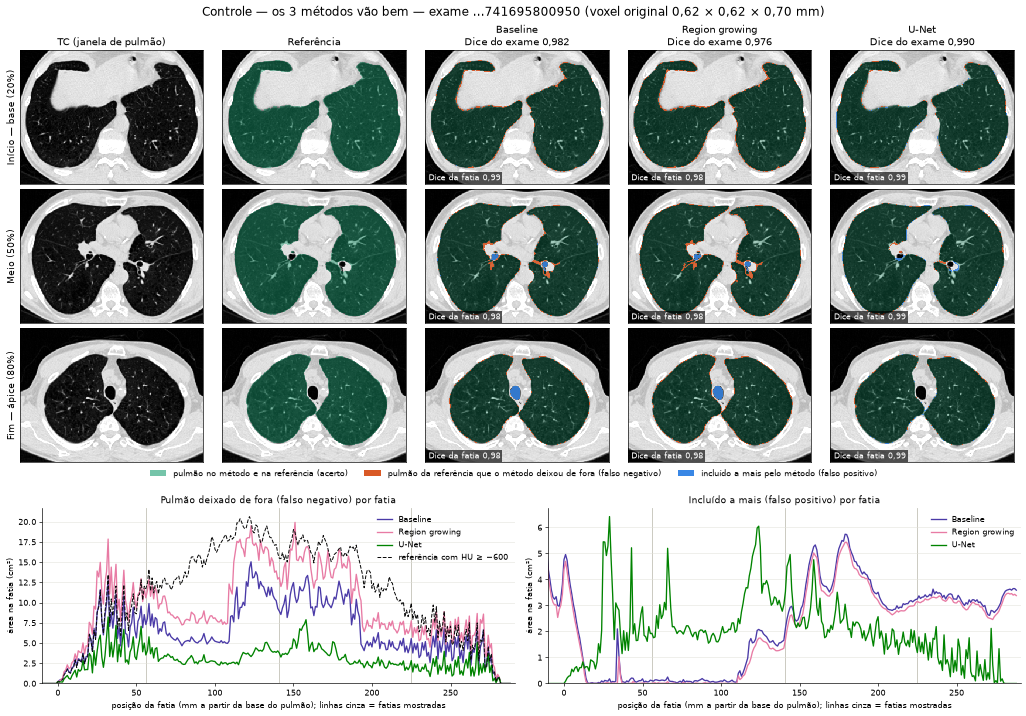

figura salva em docs\piores_casos\controle_741695800950.png


Referência: 7.18 L de pulmão; 4.6% dele com HU ≥ −600 (55% dessa parte densa na metade posterior)


,Dice,Deixado de fora (cm³),… a ≤ 2 mm da borda (%),… HU mediano,… acima de −100 HU (%),Incluído a mais (cm³),… em traqueia/brônquios (%),… fora do corpo (%)
Baseline,0.982,190,80,-415,13,72,73,0
Region growing,0.976,274,79,-499,9,66,77,0
U-Net,0.990,85,93,-401,10,58,5,0


In [9]:
exames_slide['controle'] = analisar('1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637338639741695800950', 'controle', 'Controle — os 3 métodos vão bem')

**O que a imagem mostra.** Pulmão grande (7,2 L na referência), escuro e homogêneo, com fatias
finas (0,7 mm): só 4,6% da referência está acima de −600 HU, e essa parte se espalha pela borda em
vez de se concentrar atrás.

**Por que os três acertam.** Quando o pulmão é ar escuro e homogêneo, o limiar fixo já separa
quase tudo: os três métodos acertam o miolo, e o que sobra é borda fina (80% do que o baseline deixa
de fora está a até 2 mm do contorno) e um pouco de tecido no hilo. A diferença visível é a traqueia,
que o baseline e o region growing incluem (73% do que o baseline marca a mais) e a U-Net exclui. Aqui
a U-Net só tem a borda para ganhar: +0,008 de Dice.

## 3.5 Contraponto — …696274044574 (a U-Net perde para o baseline)

Dice: baseline **0,973** · region growing **0,968** · U-Net **0,928**. Único exame em que a U-Net fica mais de 0,01 abaixo do baseline; incluído para mostrar onde a rede erra.

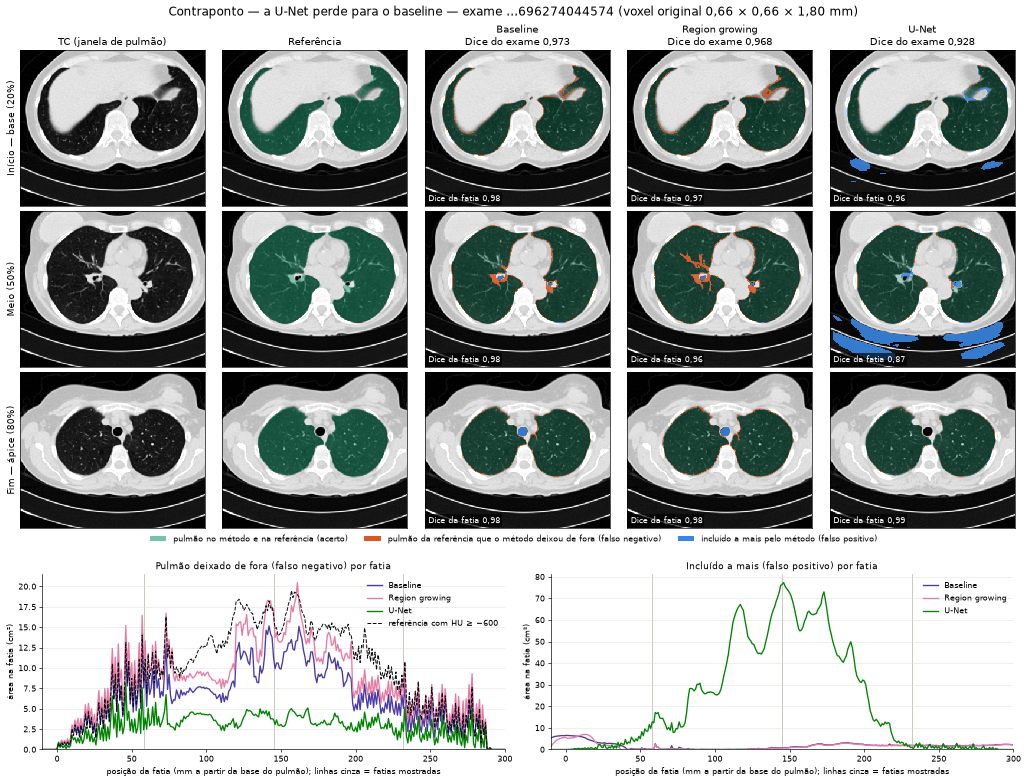

figura salva em docs\piores_casos\contraponto_696274044574.png


Referência: 4.97 L de pulmão; 5.7% dele com HU ≥ −600 (58% dessa parte densa na metade posterior)


,Dice,Deixado de fora (cm³),… a ≤ 2 mm da borda (%),… HU mediano,… acima de −100 HU (%),Incluído a mais (cm³),… em traqueia/brônquios (%),… fora do corpo (%)
Baseline,0.973,199,81,-411,13,64,46,0
Region growing,0.968,258,80,-470,10,51,56,0
U-Net,0.928,85,96,-363,14,673,0,92


In [10]:
exame = analisar('1.3.6.1.4.1.14519.5.2.1.6279.6001.238522526736091851696274044574', 'contraponto', 'Contraponto — a U-Net perde para o baseline')

**O que a imagem mostra.** Pulmão escuro e homogêneo, parecido com o controle (5,7% acima de
−600 HU). Abaixo das costas, dos dois lados da coluna, há faixas de ar entre o paciente e a mesa do
tomógrafo.

**Por que a U-Net erra aqui.** Ela marca essas faixas de ar como pulmão — 92% do que ela inclui a
mais está fora do corpo — e cai para 0,928, contra 0,973 do baseline. Os métodos clássicos não
cometem esse erro porque, depois do limiar, ficam só com os 2 maiores componentes de ar conectados
(os pulmões) e descartam o resto. A U-Net decide fatia a fatia, pela aparência local, e não tem essa
restrição anatômica. Aplicar o mesmo filtro de "maiores componentes" na saída da rede é o próximo
passo natural (não testado aqui).

## 4. O padrão se repete nos 26 exames?

Nos 3 piores casos, o que o baseline perde é, quase fatia a fatia, a parte do pulmão da referência
com HU acima do limiar (linha tracejada nos perfis). Isso é esperado por construção — o baseline só
inclui um voxel acima de −600 HU se ele estiver cercado de ar —, mas falta saber se é *o* fator
dominante ou um entre vários, e se ele também explica onde a U-Net ganha.

Abaixo, para os 26 exames de teste: a fração do pulmão da referência com HU ≥ −600 (medida no volume
que os métodos recebem), o volume da referência e o espaçamento original, comparados com o Dice de
cada método (correlação de Spearman, que usa postos e por isso é menos sensível aos 3 casos extremos).

In [11]:
linhas = []
for uid in sorted(test_uids):
    ex = preparar_exame(uid)
    linhas.append({
        'uid': uid,
        'pulmão denso (%)': 100 * (ex['vol'][ex['ref']] >= THRESHOLD_HU).mean(),
        'volume da referência (L)': ex['ref'].sum() / 1e6,
        'espessura de fatia (mm)': ex['spacing'][2],
        'pixel (mm)': ex['spacing'][0],
    })
caracteristicas = pd.DataFrame(linhas).set_index('uid').join(dice)
caracteristicas.to_csv(FIG_DIR / 'caracteristicas_26_exames.csv', float_format='%.4f')

sem_piores = caracteristicas.drop(piores.index)
ALVOS = {  # rótulo: (tabela, coluna)
    'Dice baseline': (caracteristicas, 'Baseline'),
    'Dice U-Net': (caracteristicas, 'U-Net'),
    'Ganho U-Net − baseline': (caracteristicas, 'Ganho U-Net − baseline'),
    'Ganho, sem os 3 piores': (sem_piores, 'Ganho U-Net − baseline'),
}
correlacoes = []
for var in ['pulmão denso (%)', 'volume da referência (L)', 'espessura de fatia (mm)', 'pixel (mm)']:
    for alvo, (df, coluna) in ALVOS.items():
        r = spearmanr(df[var], df[coluna])
        correlacoes.append({'variável do exame': var, 'comparada com': alvo, 'N': len(df),
                            'ρ de Spearman': r.statistic, 'p-valor': r.pvalue})
correlacoes = pd.DataFrame(correlacoes)
display(correlacoes.pivot(index='variável do exame', columns='comparada com', values='ρ de Spearman').round(2))
display(correlacoes.round(4))
display(caracteristicas.sort_values('pulmão denso (%)', ascending=False).head(6)
        .set_axis(caracteristicas.sort_values('pulmão denso (%)', ascending=False).index[:6].map(curto)).round(3))

comparada com,Dice U-Net,Dice baseline,Ganho U-Net − baseline,"Ganho, sem os 3 piores"
variável do exame,,,,
espessura de fatia (mm),-0.28,-0.38,0.20,0.25
pixel (mm),0.01,-0.12,0.26,0.30
pulmão denso (%),-0.62,-0.96,0.74,0.62
volume da referência (L),0.68,0.74,-0.41,-0.17


,variável do exame,comparada com,N,ρ de Spearman,p-valor
0,pulmão denso (%),Dice baseline,26,-0.9597,0.0000
1,pulmão denso (%),Dice U-Net,26,-0.6178,0.0008
2,pulmão denso (%),Ganho U-Net − baseline,26,0.7395,0.0000
3,pulmão denso (%),"Ganho, sem os 3 piores",23,0.6235,0.0015
4,volume da referência (L),Dice baseline,26,0.7415,0.0000
5,volume da referência (L),Dice U-Net,26,0.6766,0.0001
6,volume da referência (L),Ganho U-Net − baseline,26,-0.4072,0.0390
7,volume da referência (L),"Ganho, sem os 3 piores",23,-0.1680,0.4436
8,espessura de fatia (mm),Dice baseline,26,-0.3835,0.0531
9,espessura de fatia (mm),Dice U-Net,26,-0.2818,0.1631


,pulmão denso (%),volume da referência (L),espessura de fatia (mm),pixel (mm),Baseline,Region growing,U-Net,Ganho U-Net − baseline
uid,,,,,,,,
…658609808059,27.590,1.400,1.25,0.549,0.847,0.779,0.967,0.120
…021509831276,26.270,2.643,2.50,0.742,0.860,0.594,0.963,0.103
…954024478441,20.234,2.800,1.25,0.859,0.912,0.921,0.971,0.059
…604069960014,12.116,2.633,2.50,0.664,0.952,0.960,0.969,0.017
…326263147663,10.502,3.444,1.25,0.525,0.958,0.952,0.978,0.020
…272378865145,9.030,4.800,2.50,0.645,0.956,0.930,0.981,0.025


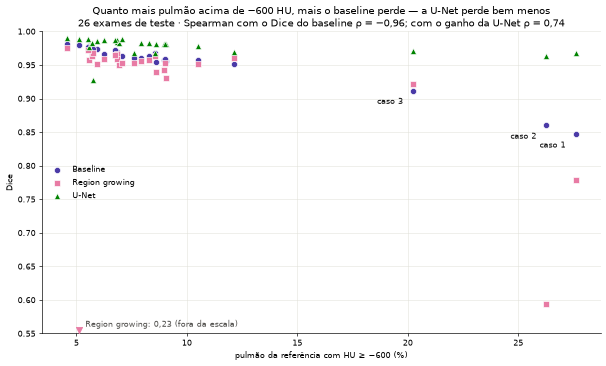

figura salva em docs\piores_casos\dice_vs_pulmao_denso.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
Y_MIN = 0.55
x = caracteristicas['pulmão denso (%)']
for nome, marcador in [('Baseline', 'o'), ('Region growing', 's'), ('U-Net', '^')]:
    y = caracteristicas[nome]
    dentro = y >= Y_MIN
    ax.scatter(x[dentro], y[dentro], s=55, marker=marcador, color=COR_METODO[nome], label=nome,
               edgecolor='white', linewidth=0.8, zorder=3)
    for uid in y.index[~dentro]:  # fora da escala: desenha na borda com o valor escrito
        ax.scatter(x[uid], Y_MIN + 0.005, s=55, marker='v', color=COR_METODO[nome], zorder=3)
        ax.annotate(f'{nome}: {fmt(y[uid], 2)} (fora da escala)', (x[uid], Y_MIN + 0.005),
                    xytext=(8, 4), textcoords='offset points', fontsize=9, color='#52514e')
for i, uid in enumerate(piores.index, 1):
    ax.annotate(f'caso {i}', (x[uid], caracteristicas.loc[uid, 'Baseline']), xytext=(-12, -16),
                textcoords='offset points', fontsize=10, color='#0b0b0b', ha='right')
rho_b = spearmanr(x, caracteristicas['Baseline']).statistic
rho_g = spearmanr(x, caracteristicas['Ganho U-Net − baseline']).statistic
ax.set_title('Quanto mais pulmão acima de −600 HU, mais o baseline perde — a U-Net perde bem menos\n'
             f'26 exames de teste · Spearman com o Dice do baseline ρ = {fmt(rho_b, 2).replace("-", "−")}; '
             f'com o ganho da U-Net ρ = {fmt(rho_g, 2)}', fontsize=12)
ax.set_xlabel(f'pulmão da referência com HU ≥ {LIMIAR_TXT} (%)')
ax.set_ylabel('Dice')
ax.set_ylim(Y_MIN, 1.0)
ax.grid(color='#e1e0d9', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='center left', frameon=False)
caminho = FIG_DIR / 'dice_vs_pulmao_denso.png'
fig.savefig(caminho, dpi=150, facecolor='white')
plt.show()
print(f'figura salva em {caminho}')

**Leitura.**

- **Pulmão denso é o fator dominante.** A fração de pulmão acima de −600 HU tem correlação de
  **−0,96** com o Dice do baseline. Os 3 piores exames são exatamente os 3 com mais pulmão denso
  (20–28%, contra 5–12% nos outros 23).
- **A U-Net também perde, mas bem menos**: ρ = −0,62 com o Dice dela, numa faixa muito mais
  estreita (0,96–0,97 nos 3 casos difíceis).
- **O ganho da U-Net cresce com o pulmão denso** (ρ = +0,74). A relação se mantém mesmo sem os 3
  casos extremos (ρ = +0,62 nos outros 23), ou seja, não é efeito só de 3 pontos.
- **As alternativas explicam menos.** A espessura de fatia não tem relação significativa com o ganho
  (ρ = +0,20, p = 0,34); a do caso 2 (2,5 mm) é comum no conjunto (10 dos 26 exames). O volume
  pulmonar tem relação mais fraca (ρ = −0,41 com o ganho), e exames pequenos *sem* áreas densas
  (…604069960014, 2,6 L; …280013275227, 2,9 L) ficam com o baseline acima de 0,95.

## 5. Figura para o slide: caso difícil × caso fácil

Mesma altura do pulmão (fatia do meio) nos dois exames, mesmos 5 painéis.

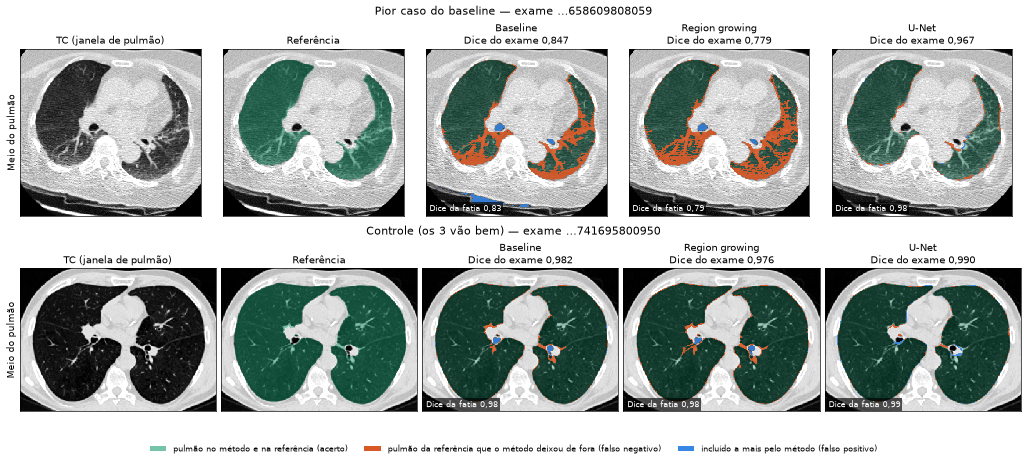

figura salva em docs\piores_casos\slide_pior_caso_vs_controle.png


In [13]:
fig = plt.figure(figsize=(17, 7.6), layout='constrained')
sub = fig.subfigures(2, 1)
for subfig, chave, rotulo in [(sub[0], 'caso1', 'Pior caso do baseline'), (sub[1], 'controle', 'Controle (os 3 vão bem)')]:
    ex = exames_slide[chave]
    ry, rx = recorte(ex)
    z_meio = escolher_fatias(ex['ref'])[1]
    ax = subfig.subplots(1, 5, squeeze=False)
    desenhar_linha_de_fatias(ax, ex, [(z_meio, 'Meio do pulmão')], ry, rx)
    subfig.suptitle(f'{rotulo} — exame {curto(ex["uid"])}', fontsize=13)
fig.legend(handles=LEGENDA_SOBREPOSICAO, loc='outside lower center', ncol=3, fontsize=10, frameon=False)
caminho = FIG_DIR / 'slide_pior_caso_vs_controle.png'
fig.savefig(caminho, dpi=150, facecolor='white')
plt.show()
print(f'figura salva em {caminho}')

## 6. Conclusão

**Sim: a U-Net ganha muito mais nos casos difíceis do que na média.** Nos 3 piores exames do
baseline ela ganha +0,094 de Dice; nos outros 23, +0,013 — cerca de 7 vezes mais justamente onde o
método clássico falha. O tipo de caso é claro nas imagens: pulmão que não é "ar escuro e homogêneo",
com uma parte grande (20–28%, contra 5–12% nos demais) acima de −600 HU — áreas cinza concentradas
atrás e nas bases, tecido denso em volta dos vasos do hilo e nódulos encostados na parede. O baseline
e o region growing decidem pelo HU de cada voxel, então deixam tudo isso de fora; a U-Net decide pela
forma e pelo contexto da fatia, inclui essas regiões e fica com erro quase só na borda. Nos 26 exames,
a fração de pulmão denso explica quase toda a variação do baseline (ρ = −0,96) e acompanha o ganho da
U-Net (ρ = +0,74, e +0,62 mesmo sem os 3 casos extremos), enquanto a espessura de fatia não tem
relação significativa. O ganho tem um custo que precisa aparecer no artigo: sem a restrição anatômica
dos métodos clássicos, a U-Net pode errar onde eles não erram — no contraponto ela marcou como pulmão
o ar entre as costas e a mesa e ficou 0,045 abaixo do baseline.